# MMAC Task 1 - Myopic Maculopathy Classification: **Baseline**


As per Category 2, AI (Claude was used as a proofreader)

## 1. Imports and setup


In [1]:
# Standard library
import json
import math
import os
import random
import time
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch + vision
import torch
import torch.nn as nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    LambdaLR,
    ReduceLROnPlateau,
    SequentialLR,
)
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from tqdm.auto import tqdm

# scikit-learn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# Styling
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")


PyTorch : 2.11.0+cu130
NumPy   : 2.4.4


## 2. Project constants and device selection


In [2]:
# Paths relative to project root
PROJECT_ROOT: Path = Path.cwd()
TRAIN_DIR: Path = PROJECT_ROOT / "data" / "Training" / "Training_Images"
TRAIN_CSV: Path = PROJECT_ROOT / "data" / "Training" / "Training_LabelsDemographic.csv"
TEST_DIR: Path = PROJECT_ROOT / "data" / "Testing" / "Testing_Images"
TEST_CSV: Path = PROJECT_ROOT / "data" / "Testing" / "Testing_LabelDemographic.csv"
CHECKPOINT_DIR: Path = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR: Path = PROJECT_ROOT / "outputs"

for path in [CHECKPOINT_DIR / "baseline", OUTPUT_DIR / "baseline"]:
    path.mkdir(parents=True, exist_ok=True)

# META-PM grades (5 classes)
NUM_CLASSES: int = 5
CLASS_NAMES: Tuple[str, ...] = (
    "0: No macular lesions",
    "1: Tessellated fundus",
    "2: Diffuse atrophy",
    "3: Patchy atrophy",
    "4: Macular atrophy",
)
LABEL_COL: str = "myopic_maculopathy_grade"
IMAGE_COL: str = "image"

# Device selection
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# ImageNet mean/std
IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device      : {get_device()}")


Project root: /home/dudu/ucl/applied_ai/cw2/AppliedAIGroupProject
Device      : cuda


## 3. Configuration - `BaselineConfig`


In [ ]:
@dataclass
class BaselineConfig:
    """All the knobs for one training run.
    """

    # Reproducibility
    seed: int = 42

    # Data
    image_size: int = 224            # ResNet-50 / ImageNet canonical input
    val_split: float = 0.15          # fraction of training set held out for validation
    num_workers: int = 4             # DataLoader workers
    batch_size: int = 16             # safe for MPS with ResNet-50 @ 224
    train_fraction: float = 1.0      # <1.0 → stratified subsample of training split
    augmentation: bool = True        # False → use eval transform for training too

    # Model
    backbone: str = "resnet50"       # torchvision backbone
    pretrained: bool = True
    dropout: float = 0.3             # applied in the new classification head

    # Training
    epochs: int = 30
    head_lr: float = 1e-3            # newly-initialised classifier head
    backbone_lr: float = 1e-4        # finetuned pretrained backbone
    weight_decay: float = 1e-4
    scheduler: str = "cosine"        # "cosine" or "plateau"
    warmup_epochs: int = 1           # linear warm-up before the main schedule
    label_smoothing: float = 0.0     # keep baseline vanilla; imbalance task may raise it
    wegihted_ce: bool = False        # whether to use weighted cross entropy loss or not  
    class_weights: torch.Tensor = None

    # Regularisation / stability
    grad_clip: float = 1.0           # global gradient-norm clip
    use_amp: bool = True             # mixed precision (auto-disabled on MPS)

    early_stop_patience: int = 7
    primary_metric: str = "quadratic_kappa"  # MMAC-style ordinal metric

    # Checkpointing / logging
    checkpoint_dir: Path = field(default_factory=lambda: CHECKPOINT_DIR / "baseline")
    output_dir: Path = field(default_factory=lambda: OUTPUT_DIR / "baseline")
    experiment_name: str = "baseline_resnet50"

    def __post_init__(self) -> None:
        self.checkpoint_dir = Path(self.checkpoint_dir)
        self.output_dir = Path(self.output_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)


## 4. Data pipeline


In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, Optional, Tuple
from dataclasses import dataclass
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

IMAGENET_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
IMAGENET_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)

def build_train_transform(image_size: int = 224) -> transforms.Compose:
    """Train-time augmentation pipeline.

    No vertical flips: they break fundus topology. Horizontal flip is OK
    because left/right eyes are approximately mirror-symmetric. Rotation
    capped at ±10° to keep macular orientation intact.
    """
    return transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.15)),
            transforms.RandomResizedCrop(
                image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )

def build_eval_transform(image_size: int = 224) -> transforms.Compose:
    """Deterministic val/test transform — no random ops."""
    return transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.15)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )

@dataclass
class MMACClassificationDataset(Dataset):
    """Yields (image, label) pairs, or (image, label, metadata_dict).

    ``frame`` is a slice of the labels CSV. ``transform=None`` returns the
    raw PIL image (handy for EDA plots). ``return_metadata=True`` switches
    on the demographic dict used by the multi-task / bias extensions.
    """

    frame: pd.DataFrame
    image_dir: Path
    transform: Optional[transforms.Compose] = None
    return_metadata: bool = False

    def __post_init__(self) -> None:
        self.frame = self.frame.reset_index(drop=True)
        self.image_dir = Path(self.image_dir)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        img_path = self.image_dir / row[IMAGE_COL]
        # force 3-channel RGB
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = int(row[LABEL_COL])

        if not self.return_metadata:
            return image, label

        meta = _encode_metadata(row)
        return image, label, meta

def _encode_metadata(row: pd.Series) -> Dict[str, torch.Tensor]:
    """Pack the demographic columns into small tensors.

    Sex maps to {male: 0, female: 1, missing: -1}. Numeric fields come with
    a companion missing-mask tensor; how to impute them is left to the
    consuming extension model.
    """
    sex_map = {"male": 0, "female": 1}
    raw_sex = row.get("sex")
    sex = sex_map.get(raw_sex, -1) if isinstance(raw_sex, str) else -1

    def _num(v: object) -> Tuple[float, float]:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return 0.0, 1.0  # value, missing-mask
        return float(v), 0.0

    age_v, age_m = _num(row.get("age"))
    h_v, h_m = _num(row.get("height"))
    w_v, w_m = _num(row.get("weight"))

    return {
        "sex": torch.tensor(sex, dtype=torch.long),
        "age": torch.tensor(age_v, dtype=torch.float32),
        "age_missing": torch.tensor(age_m, dtype=torch.float32),
        "height": torch.tensor(h_v, dtype=torch.float32),
        "height_missing": torch.tensor(h_m, dtype=torch.float32),
        "weight": torch.tensor(w_v, dtype=torch.float32),
        "weight_missing": torch.tensor(w_m, dtype=torch.float32),
        "data_center": torch.tensor(int(row.get("data_center", 0)), dtype=torch.long),
    }

def load_label_frame(csv_path: Path, image_dir: Path) -> pd.DataFrame:
    """Read the labels CSV and drop rows whose image file isn't on disk."""
    frame = pd.read_csv(csv_path)
    exists = frame[IMAGE_COL].apply(lambda n: (Path(image_dir) / n).is_file())
    missing = (~exists).sum()
    if missing:
        print(f"[data] Dropping {missing} rows with missing image files in {image_dir}")
        frame = frame[exists].reset_index(drop=True)
    return frame

def stratified_split(
    frame: pd.DataFrame,
    val_fraction: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Stratified train/val split. Grades 3/4 are <10% of train, so a
    plain random split can leave them missing from val."""
    train_idx, val_idx = train_test_split(
        np.arange(len(frame)),
        test_size=val_fraction,
        random_state=seed,
        shuffle=True,
        stratify=frame[LABEL_COL].values,
    )
    train_frame = frame.iloc[train_idx].reset_index(drop=True)
    val_frame = frame.iloc[val_idx].reset_index(drop=True)
    return train_frame, val_frame

def stratified_subsample(
    frame: pd.DataFrame,
    fraction: float,
    seed: int,
) -> pd.DataFrame:
    """Keep ~``fraction`` of the rows, stratified by label.

    Used for the learning-curve ablation (30/60/100%). Always run this
    *after* the train/val split so val + test stay identical across every
    point on the curve.
    """
    if fraction >= 1.0:
        return frame.reset_index(drop=True)
    if fraction <= 0.0:
        raise ValueError(f"train_fraction must be > 0, got {fraction}")
    keep_idx, _ = train_test_split(
        np.arange(len(frame)),
        train_size=fraction,
        random_state=seed,
        shuffle=True,
        stratify=frame[LABEL_COL].values,
    )
    return frame.iloc[keep_idx].reset_index(drop=True)

def build_dataloaders(
    config: BaselineConfig,
    return_metadata: bool = False,
) -> Dict[str, DataLoader]:
    """Read CSVs, split, build datasets, return train/val/test DataLoaders.

    The raw Datasets are also stashed under ``train_ds``/``val_ds``/
    ``test_ds`` so callers can poke at the frames (EDA, class weights,
    ...) without re-reading the CSV.
    """
    train_frame = load_label_frame(TRAIN_CSV, TRAIN_DIR)
    test_frame = load_label_frame(TEST_CSV, TEST_DIR)

    train_frame, val_frame = stratified_split(
        train_frame, val_fraction=config.val_split, seed=config.seed
    )

    if getattr(config, "train_fraction", 1.0) < 1.0:
        before = len(train_frame)
        train_frame = stratified_subsample(
            train_frame, config.train_fraction, config.seed
        )
        print(
            f"[data] train_fraction={config.train_fraction}: "
            f"reduced training set from {before} to {len(train_frame)} images"
        )

    eval_tfm = build_eval_transform(config.image_size)
    train_tfm = (
        build_train_transform(config.image_size)
        if getattr(config, "augmentation", True)
        else eval_tfm
    )
    if not getattr(config, "augmentation", True):
        print("[data] augmentation=False: training uses the eval transform")

    train_ds = MMACClassificationDataset(
        train_frame, TRAIN_DIR, transform=train_tfm, return_metadata=return_metadata
    )
    val_ds = MMACClassificationDataset(
        val_frame, TRAIN_DIR, transform=eval_tfm, return_metadata=return_metadata
    )
    test_ds = MMACClassificationDataset(
        test_frame, TEST_DIR, transform=eval_tfm, return_metadata=return_metadata
    )

    common_kwargs = dict(
        batch_size=config.batch_size,
        num_workers=config.num_workers,
        pin_memory=True,
        persistent_workers=config.num_workers > 0,
    )

    # CHANGED
    # class_counts = train_frame[LABEL_COL].value_counts().sort_index().values
    # class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    # print("Class weights: ", class_weights)
    # train_targets = torch.tensor(train_frame[LABEL_COL].values)
    # sample_weights = [class_weights[t] for t in train_targets]

    # sampler = WeightedRandomSampler(
    #     weights=sample_weights,
    #     num_samples=len(sample_weights),
    #     replacement=True
    # )

    loaders = {
        # "train": DataLoader(train_ds, shuffle=False, drop_last=True, sampler=sampler, **common_kwargs),
        "train": DataLoader(train_ds, shuffle=True, drop_last=True, **common_kwargs),
        "val": DataLoader(val_ds, shuffle=False, drop_last=False, **common_kwargs),
        "test": DataLoader(test_ds, shuffle=False, drop_last=False, **common_kwargs),
    }
    loaders["train_ds"] = train_ds
    loaders["val_ds"] = val_ds
    loaders["test_ds"] = test_ds
    return loaders

def class_counts(frame: pd.DataFrame, num_classes: int = NUM_CLASSES) -> np.ndarray:
    """Per-class row counts as an int array of length ``num_classes``."""
    counts = np.zeros(num_classes, dtype=np.int64)
    for k, v in frame[LABEL_COL].value_counts().items():
        counts[int(k)] = int(v)
    return counts

def inverse_frequency_weights(
    frame: pd.DataFrame, num_classes: int = NUM_CLASSES
) -> torch.Tensor:
    """1/frequency class weights, rescaled to sum to ``num_classes``.

    Baseline ignores this; exposed here so the imbalance extension has
    a single place to import from.
    """
    counts = class_counts(frame, num_classes).astype(np.float64)
    counts = np.where(counts == 0, 1, counts)
    weights = counts.sum() / counts
    weights = weights * (num_classes / weights.sum())
    return torch.tensor(weights, dtype=torch.float32)


## 5. Model - `MMACResNet50`


In [77]:
import torch
import torch.nn as nn
from typing import List, Tuple
from torchvision import models
from torchvision.models import ResNet50_Weights

class MMACResNet50(nn.Module):
    """ResNet-50 backbone + a small MLP head (2048→512→5).

    Linear-BN-ReLU-Dropout-Linear. The extra hidden layer gives the
    network a little room to remap ImageNet features onto the 5 grades
    without blowing the parameter budget. Dropout rate is set by
    ``BaselineConfig.dropout``.
    """

    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        pretrained: bool = True,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  # strip the original 1000-class head

        self.head = nn.Sequential(
            # CHANGED
            # nn.Linear(in_features, 512),
            nn.Linear(2 * in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )

        # init new layers
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # CHANGED
    # def forward(self, x: torch.Tensor) -> torch.Tensor:
    #     features = self.backbone(x)
    #     return self.head(features)

    # ResNet-50’s default forward uses Global Average Pooling.
    # While good for general objects, combining Average Pooling and Max Pooling gives the MLP head two different perspectives: 
    # the "average" state of the retina and the "most extreme" lesion found.
    # For small lesions like patchy atrophy (Grade 3), GAP can sometimes "wash out" the signal.
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Get features from backbone before the Identity() layer
        # ResNet50 features are [Batch, 2048, 7, 7] before pooling
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        avg_pool = torch.mean(x, dim=[2, 3])
        max_pool = torch.amax(x, dim=(2, 3))
        
        # Concatenate them: features now 4096 instead of 2048
        combined_features = torch.cat([avg_pool, max_pool], dim=1)
        return self.head(combined_features)

    def parameter_groups(
        self, backbone_lr: float, head_lr: float, weight_decay: float
    ) -> List[dict]:
        """Two param groups so the optimiser can give the fresh head a
        higher LR than the pretrained backbone."""
        return [
            {
                "params": list(self.backbone.parameters()),
                "lr": backbone_lr,
                "weight_decay": weight_decay,
                "name": "backbone",
            },
            {
                "params": list(self.head.parameters()),
                "lr": head_lr,
                "weight_decay": weight_decay,
                "name": "head",
            },
        ]

def build_model(config: BaselineConfig) -> MMACResNet50:
    """Build the model from config. Keeps architecture code out of the notebook."""
    if config.backbone != "resnet50":
        raise ValueError(
            f"Baseline only supports ResNet-50; got {config.backbone!r}. "
            "Extension models can override this."
        )
    return MMACResNet50(
        num_classes=NUM_CLASSES,
        pretrained=config.pretrained,
        dropout=config.dropout,
    )

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """(trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


## 6. Metrics and bootstrap inference


In [54]:
import numpy as np
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, f1_score, precision_recall_fscore_support, roc_auc_score,
)

_SCALAR_METRICS: Tuple[str, ...] = (
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "quadratic_kappa",
    "macro_auroc",
)

@dataclass
class MetricBundle:
    """One epoch's worth of metrics."""

    accuracy: float
    balanced_accuracy: float
    macro_f1: float
    weighted_f1: float
    quadratic_kappa: float
    macro_auroc: Optional[float]
    per_class_precision: List[float] = field(default_factory=list)
    per_class_recall: List[float] = field(default_factory=list)
    per_class_f1: List[float] = field(default_factory=list)
    per_class_support: List[int] = field(default_factory=list)
    confusion_matrix: List[List[int]] = field(default_factory=list)

    def to_dict(self) -> Dict[str, object]:
        """Flat dict for JSON logging."""
        return {
            "accuracy": self.accuracy,
            "balanced_accuracy": self.balanced_accuracy,
            "macro_f1": self.macro_f1,
            "weighted_f1": self.weighted_f1,
            "quadratic_kappa": self.quadratic_kappa,
            "macro_auroc": self.macro_auroc,
            "per_class_precision": self.per_class_precision,
            "per_class_recall": self.per_class_recall,
            "per_class_f1": self.per_class_f1,
            "per_class_support": self.per_class_support,
            "confusion_matrix": self.confusion_matrix,
        }

    def pretty(self) -> str:
        auroc = (
            f"{self.macro_auroc:.4f}"
            if self.macro_auroc is not None and np.isfinite(self.macro_auroc)
            else "  n/a"
        )
        return (
            f"acc={self.accuracy:.4f}  bal_acc={self.balanced_accuracy:.4f}  "
            f"macroF1={self.macro_f1:.4f}  kappa={self.quadratic_kappa:.4f}  "
            f"AUROC={auroc}"
        )

def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None,
    num_classes: int = NUM_CLASSES,
) -> MetricBundle:
    
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    labels = list(range(num_classes))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic")
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    auroc: Optional[float] = None
    if y_prob is not None:
        y_prob = np.asarray(y_prob)
        present = np.unique(y_true)
        if len(present) >= 2:
            try:
                auroc = roc_auc_score(y_true, y_prob, multi_class="ovr",
                                      average="macro", labels=labels)
                if auroc is not None and not np.isfinite(auroc):
                    auroc = roc_auc_score(y_true, y_prob[:, present],
                                          multi_class="ovr", average="macro",
                                          labels=present.tolist())
                    if auroc is not None and not np.isfinite(auroc):
                        auroc = None
            except ValueError:
                auroc = None

    return MetricBundle(
        accuracy=float(acc), balanced_accuracy=float(bal_acc),
        macro_f1=float(macro_f1), weighted_f1=float(weighted_f1),
        quadratic_kappa=float(kappa),
        macro_auroc=float(auroc) if auroc is not None else None,
        per_class_precision=[float(p) for p in precision],
        per_class_recall=[float(r) for r in recall],
        per_class_f1=[float(f) for f in f1_per_class],
        per_class_support=[int(s) for s in support],
        confusion_matrix=[[int(x) for x in row] for row in cm],
    )

def _stratified_bootstrap_index(y_true: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """One stratified resample (with replacement) for bootstrap inference."""
    idx_out = np.empty_like(y_true, dtype=np.int64)
    pos = 0
    for c in np.unique(y_true):
        class_idx = np.flatnonzero(y_true == c)
        draws = rng.integers(0, len(class_idx), size=len(class_idx))
        idx_out[pos : pos + len(class_idx)] = class_idx[draws]
        pos += len(class_idx)
    return idx_out

def bootstrap_metrics(
    y_true: np.ndarray, y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None, *,
    num_classes: int = NUM_CLASSES, n_resamples: int = 1000,
    ci_level: float = 0.95, seed: int = 42,
) -> Dict[str, Dict[str, float]]:
    """Percentile-bootstrap CIs for every scalar metric."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if y_prob is not None:
        y_prob = np.asarray(y_prob)

    point = compute_metrics(y_true, y_pred, y_prob, num_classes=num_classes)
    point_dict = point.to_dict()
    samples: Dict[str, List[float]] = {m: [] for m in _SCALAR_METRICS}
    rng = np.random.default_rng(seed)

    for _ in range(n_resamples):
        idx = _stratified_bootstrap_index(y_true, rng)
        b = compute_metrics(y_true[idx], y_pred[idx],
                            y_prob[idx] if y_prob is not None else None,
                            num_classes=num_classes)
        for m in _SCALAR_METRICS:
            v = getattr(b, m)
            if v is not None and np.isfinite(v):
                samples[m].append(float(v))

    alpha = (1.0 - ci_level) / 2.0
    results: Dict[str, Dict[str, float]] = {}
    for m in _SCALAR_METRICS:
        arr = np.asarray(samples[m], dtype=float)
        point_val = point_dict.get(m)
        point_val = float(point_val) if point_val is not None else float("nan")
        if arr.size == 0:
            results[m] = {"point": point_val, "ci_low": float("nan"),
                          "ci_high": float("nan"), "std": float("nan")}
            continue
        lo, hi = np.quantile(arr, [alpha, 1.0 - alpha])
        results[m] = {"point": point_val, "ci_low": float(lo),
                       "ci_high": float(hi),
                       "std": float(arr.std(ddof=1)) if arr.size > 1 else 0.0}
    return results

def format_ci(ci: Dict[str, float], digits: int = 4) -> str:
    """Format as ``0.7412 [0.6891, 0.7893]``."""
    p = ci.get("point", float("nan"))
    lo = ci.get("ci_low", float("nan"))
    hi = ci.get("ci_high", float("nan"))
    if not (np.isfinite(p) and np.isfinite(lo) and np.isfinite(hi)):
        return f"{p:.{digits}f}  [n/a]"
    return f"{p:.{digits}f}  [{lo:.{digits}f}, {hi:.{digits}f}]"

def paired_bootstrap_compare(
    y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray,
    y_prob_a: Optional[np.ndarray] = None,
    y_prob_b: Optional[np.ndarray] = None, *,
    num_classes: int = NUM_CLASSES, metric: str = "quadratic_kappa",
    n_resamples: int = 2000, ci_level: float = 0.95, seed: int = 42,
) -> Dict[str, float]:
    """Paired bootstrap comparison of two models on the same test set."""
    y_true = np.asarray(y_true).astype(int)
    y_pred_a = np.asarray(y_pred_a).astype(int)
    y_pred_b = np.asarray(y_pred_b).astype(int)
    if y_prob_a is not None: y_prob_a = np.asarray(y_prob_a)
    if y_prob_b is not None: y_prob_b = np.asarray(y_prob_b)

    def _scalar(y, p, q):
        bundle = compute_metrics(y, p, q, num_classes=num_classes)
        v = getattr(bundle, metric)
        return float(v) if v is not None and np.isfinite(v) else np.nan

    metric_a = _scalar(y_true, y_pred_a, y_prob_a)
    metric_b = _scalar(y_true, y_pred_b, y_prob_b)
    delta_point = metric_a - metric_b

    rng = np.random.default_rng(seed)
    deltas: List[float] = []
    for _ in range(n_resamples):
        idx = _stratified_bootstrap_index(y_true, rng)
        va = _scalar(y_true[idx], y_pred_a[idx],
                     y_prob_a[idx] if y_prob_a is not None else None)
        vb = _scalar(y_true[idx], y_pred_b[idx],
                     y_prob_b[idx] if y_prob_b is not None else None)
        if np.isfinite(va) and np.isfinite(vb):
            deltas.append(va - vb)

    arr = np.asarray(deltas, dtype=float)
    alpha_val = (1.0 - ci_level) / 2.0
    lo, hi = np.quantile(arr, [alpha_val, 1.0 - alpha_val]) if arr.size else (np.nan, np.nan)

    if arr.size == 0 or not np.isfinite(delta_point):
        p_value = float("nan")
    else:
        if delta_point >= 0:
            tail = float((arr <= 0).sum()) / arr.size
        else:
            tail = float((arr >= 0).sum()) / arr.size
        p_value = min(1.0, 2.0 * tail)

    return {"metric_a": metric_a, "metric_b": metric_b, "delta": delta_point,
            "ci_low": float(lo), "ci_high": float(hi), "p_value": p_value,
            "n_resamples": int(arr.size)}


## 7. Utilities


In [75]:
import json
import os
import random
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed: int, deterministic: bool = False) -> None:
    """Seed python/numpy/torch RNGs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def enable_cuda_optimizations(use_tf32: bool = True) -> None:
    
    if not torch.cuda.is_available():
        return
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    if use_tf32:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

def unwrap_model(model: torch.nn.Module) -> torch.nn.Module:
    """Strip DataParallel if present, return the inner module otherwise."""
    if isinstance(model, torch.nn.DataParallel):
        return model.module
    return model

def save_checkpoint(
    path: Path, *, model: torch.nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[object] = None, epoch: int,
    metrics: Optional[Dict[str, Any]] = None,
    extra: Optional[Dict[str, Any]] = None,
) -> None:
    """Write a full training checkpoint to ``path``."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload: Dict[str, Any] = {
        "epoch": int(epoch),
        "model_state": unwrap_model(model).state_dict(),
        "metrics": metrics or {},
        "extra": extra or {},
    }
    if optimizer is not None:
        payload["optimizer_state"] = optimizer.state_dict()
    if scheduler is not None and hasattr(scheduler, "state_dict"):
        payload["scheduler_state"] = scheduler.state_dict()
    torch.save(payload, path)

def load_checkpoint(
    path: Path, *, model: Optional[torch.nn.Module] = None,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[object] = None,
    map_location: Optional[str] = "cpu",
) -> Dict[str, Any]:
    """Load a checkpoint, optionally restoring model/optimiser/scheduler state."""
    payload = torch.load(path, map_location=map_location)
    if model is not None and "model_state" in payload:
        unwrap_model(model).load_state_dict(payload["model_state"])
    if optimizer is not None and "optimizer_state" in payload:
        optimizer.load_state_dict(payload["optimizer_state"])
    if scheduler is not None and "scheduler_state" in payload:
        scheduler.load_state_dict(payload["scheduler_state"])
    return payload

@dataclass
class TrainingHistory:
    """Per-epoch scalar log."""

    train_loss: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    train_metrics: List[Dict[str, Any]] = field(default_factory=list)
    val_metrics: List[Dict[str, Any]] = field(default_factory=list)
    learning_rates: List[List[float]] = field(default_factory=list)

    def append(self, *, train_loss: float, val_loss: float,
               train_metrics: Dict[str, Any], val_metrics: Dict[str, Any],
               learning_rates: List[float]) -> None:
        self.train_loss.append(float(train_loss))
        self.val_loss.append(float(val_loss))
        self.train_metrics.append(train_metrics)
        self.val_metrics.append(val_metrics)
        self.learning_rates.append([float(lr) for lr in learning_rates])

    def save(self, path: Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open("w") as f:
            json.dump(self.__dict__, f, indent=2, default=_json_default)

def _json_default(obj: Any) -> Any:
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(f"Not serializable: {type(obj)}")

def plot_training_curves(history: "TrainingHistory", save_path: Optional[Path] = None):
    """Loss + primary-metric curves. Returns the figure."""
    epochs = np.arange(1, len(history.train_loss) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history.train_loss, marker="o", label="train")
    axes[0].plot(epochs, history.val_loss, marker="o", label="val")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross-entropy loss")
    axes[0].set_title("Training / validation loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    train_kappa = [m.get("quadratic_kappa", np.nan) for m in history.train_metrics]
    val_kappa = [m.get("quadratic_kappa", np.nan) for m in history.val_metrics]
    val_acc = [m.get("accuracy", np.nan) for m in history.val_metrics]
    val_bal = [m.get("balanced_accuracy", np.nan) for m in history.val_metrics]

    axes[1].plot(epochs, train_kappa, marker="o", label="train k")
    axes[1].plot(epochs, val_kappa, marker="o", label="val k")
    axes[1].plot(epochs, val_acc, marker="s", linestyle="--", label="val acc")
    axes[1].plot(epochs, val_bal, marker="^", linestyle="--", label="val bal acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("metric")
    axes[1].set_title("Validation metrics (primary: quadratic k)")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

def plot_confusion_matrix(
    cm: np.ndarray, class_names: List[str], normalize: bool = True,
    save_path: Optional[Path] = None, title: str = "Confusion matrix",
):
    """Seaborn heatmap, row-normalised by default so the diagonal reads as recall."""
    cm = np.asarray(cm, dtype=np.float64)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm, row_sums, where=row_sums > 0)
        fmt = ".2f"
    else:
        cm_display = cm
        fmt = ".0f"

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar=True, ax=ax)
    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title + (" (row-normalised)" if normalize else ""))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


## 8. Training engine


In [ ]:
import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import (
    CosineAnnealingLR, LambdaLR, ReduceLROnPlateau, SequentialLR,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def build_optimizer(model: nn.Module, config: BaselineConfig) -> Optimizer:
    """AdamW with a lower LR on the pretrained backbone than on the head.

    Unwraps DataParallel first so ``parameter_groups`` is called on the
    real module (DataParallel doesn't forward custom methods).
    """
    param_groups = unwrap_model(model).parameter_groups(
        backbone_lr=config.backbone_lr,
        head_lr=config.head_lr,
        weight_decay=config.weight_decay,
    )
    return AdamW(param_groups)

def build_scheduler(
    optimizer: Optimizer,
    config: BaselineConfig,
    steps_per_epoch: int,
):
    """Linear warmup → cosine (or plateau) schedule.

    Warmup happens in epoch units — at epoch ``k`` the LR is ``(k+1)/warmup``
    times the base LR, then the main schedule takes over.
    """
    base_scheduler = (
        CosineAnnealingLR(
            optimizer,
            T_max=max(1, config.epochs - config.warmup_epochs),
            eta_min=0.0,
        )
        if config.scheduler == "cosine"
        else ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7
        )
    )
    if config.warmup_epochs <= 0:
        return base_scheduler

    warmup = LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: float(epoch + 1) / max(1, config.warmup_epochs),
    )
    if isinstance(base_scheduler, ReduceLROnPlateau):
                return {"warmup": warmup, "main": base_scheduler}
    return SequentialLR(
        optimizer, schedulers=[warmup, base_scheduler], milestones=[config.warmup_epochs]
    )

def _build_amp_scaler(use_amp: bool, device: torch.device) -> Optional[torch.cuda.amp.GradScaler]:

    if use_amp and device.type == "cuda":
        return torch.amp.GradScaler('cuda')
    return None

def _autocast_context(use_amp: bool, device: torch.device):

    if use_amp and device.type == "cuda":
        return torch.amp.autocast('cuda')
    class _Null:
        def __enter__(self_inner): return None
        def __exit__(self_inner, *exc): return False
    return _Null()

def _move_batch(batch, device: torch.device):
    """Push a (x, y) or (x, y, meta_dict) batch to device."""
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        x, y = batch[0].to(device, non_blocking=True), batch[1].to(
            device, non_blocking=True
        )
        rest = list(batch[2:])
        rest = [
            {k: v.to(device, non_blocking=True) for k, v in r.items()}
            if isinstance(r, dict)
            else r.to(device, non_blocking=True)
            for r in rest
        ]
        return (x, y, *rest) if rest else (x, y)
    raise ValueError("Unexpected batch format")

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optimizer,
    criterion: nn.Module,
    device: torch.device,
    *,
    grad_clip: float = 0.0,
    use_amp: bool = False,
    epoch: int = 0,
    total_epochs: int = 0,
) -> Tuple[float, MetricBundle]:

    model.train()
    scaler = _build_amp_scaler(use_amp, device)

    running_loss = 0.0
    seen = 0
    all_targets: List[np.ndarray] = []
    all_preds: List[np.ndarray] = []
    all_probs: List[np.ndarray] = []

    pbar = tqdm(
        loader,
        desc=f"train {epoch + 1}/{total_epochs}",
        leave=False,
        dynamic_ncols=True,
    )
    for batch in pbar:
        x, y, *_ = _move_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)
        with _autocast_context(use_amp, device):
            logits = model(x)
            loss = criterion(logits, y)

        if scaler is not None:
            scaler.scale(loss).backward()
            if grad_clip and grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip and grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        bs = x.size(0)
        running_loss += float(loss.detach()) * bs
        seen += bs

        with torch.no_grad():
            probs = torch.softmax(logits.detach(), dim=1).float().cpu().numpy()
            preds = probs.argmax(axis=1)
            all_targets.append(y.detach().cpu().numpy())
            all_preds.append(preds)
            all_probs.append(probs)

        pbar.set_postfix(loss=f"{running_loss / max(seen, 1):.4f}")

    y_true = np.concatenate(all_targets) if all_targets else np.array([], dtype=int)
    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=int)
    y_prob = np.concatenate(all_probs) if all_probs else None
    metrics = compute_metrics(y_true, y_pred, y_prob)
    return running_loss / max(seen, 1), metrics

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    *,
    desc: str = "eval",
) -> Tuple[float, MetricBundle, np.ndarray, np.ndarray, np.ndarray]:
 
    model.eval()
    running_loss = 0.0
    seen = 0
    all_targets: List[np.ndarray] = []
    all_preds: List[np.ndarray] = []
    all_probs: List[np.ndarray] = []

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    for batch in pbar:
        x, y, *_ = _move_batch(batch, device)
        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1).float().cpu().numpy()
        preds = probs.argmax(axis=1)
        all_targets.append(y.cpu().numpy())
        all_preds.append(preds)
        all_probs.append(probs)

        bs = x.size(0)
        running_loss += float(loss) * bs
        seen += bs
        pbar.set_postfix(loss=f"{running_loss / max(seen, 1):.4f}")

    y_true = np.concatenate(all_targets) if all_targets else np.array([], dtype=int)
    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=int)
    y_prob = np.concatenate(all_probs) if all_probs else np.empty((0, 0))
    bundle = compute_metrics(y_true, y_pred, y_prob)
    return running_loss / max(seen, 1), bundle, y_true, y_pred, y_prob

@dataclass
class TrainResult:
    history: TrainingHistory
    best_epoch: int
    best_metric: float
    best_ckpt_path: Path
    last_ckpt_path: Path
    primary_metric: str

def load_trained_result(config: BaselineConfig) -> TrainResult:

    import json

    best_ckpt = config.checkpoint_dir / f"{config.experiment_name}_best.pt"
    last_ckpt = config.checkpoint_dir / f"{config.experiment_name}_last.pt"
    history_path = config.output_dir / f"{config.experiment_name}_history.json"

    if not best_ckpt.is_file():
        raise FileNotFoundError(
            f"Best checkpoint not found at {best_ckpt}. Train the baseline "
            "locally or copy the artefacts from the VPS before calling "
            "load_trained_result()."
        )
    if not history_path.is_file():
        raise FileNotFoundError(
            f"Training history not found at {history_path}."
        )

    with history_path.open() as f:
        raw = json.load(f)

    history = TrainingHistory(
        train_loss=list(raw.get("train_loss", [])),
        val_loss=list(raw.get("val_loss", [])),
        train_metrics=list(raw.get("train_metrics", [])),
        val_metrics=list(raw.get("val_metrics", [])),
        learning_rates=list(raw.get("learning_rates", [])),
    )

    val_metric_series = [
        m.get(config.primary_metric, -math.inf) for m in history.val_metrics
    ]
    if val_metric_series:
        best_epoch = int(max(range(len(val_metric_series)), key=val_metric_series.__getitem__))
        best_metric = float(val_metric_series[best_epoch])
    else:
        best_epoch = -1
        best_metric = float("nan")

    return TrainResult(
        history=history,
        best_epoch=best_epoch,
        best_metric=best_metric,
        best_ckpt_path=best_ckpt,
        last_ckpt_path=last_ckpt,
        primary_metric=config.primary_metric,
    )

def train(
    model: nn.Module,
    loaders: Dict[str, DataLoader],
    config: BaselineConfig,
    device: torch.device,
    *,
    criterion: Optional[nn.Module] = None,
) -> TrainResult:
    """End-to-end training loop with checkpointing + early stopping.

    Watches ``config.primary_metric`` on val and stops after
    ``config.early_stop_patience`` epochs without improvement. Best
    (by that metric) and last checkpoints are always written.
    """
    model.to(device)

    # multi-GPU
    if device.type == "cuda" and torch.cuda.device_count() > 1:
        gpu_ids = list(range(torch.cuda.device_count()))
        print(
            f"[train] Using nn.DataParallel across {len(gpu_ids)} GPUs: {gpu_ids}"
        )
        model = nn.DataParallel(model, device_ids=gpu_ids)

    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
        if config.class_weights:
            class_weights = inverse_frequency_weights(loaders["train_ds"])
            print("Loss class weights: ", class_weights)
            class_weights = class_weights.to(device)
            criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing, weight=class_weights)
        

    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, steps_per_epoch=len(loaders["train"]))

    history = TrainingHistory()
    best_metric = -math.inf
    best_epoch = -1
    patience_left = config.early_stop_patience

    best_ckpt = config.checkpoint_dir / f"{config.experiment_name}_best.pt"
    last_ckpt = config.checkpoint_dir / f"{config.experiment_name}_last.pt"

    use_amp = config.use_amp and device.type == "cuda"

    print(
        f"[train] device={device.type}  epochs={config.epochs}  "
        f"batch_size={config.batch_size}  primary_metric={config.primary_metric}"
    )

    for epoch in range(config.epochs):
        t0 = time.time()

        if isinstance(scheduler, dict):
            active = scheduler["warmup"] if epoch < config.warmup_epochs else scheduler["main"]
        else:
            active = scheduler

        train_loss, train_metrics = train_one_epoch(
            model,
            loaders["train"],
            optimizer,
            criterion,
            device,
            grad_clip=config.grad_clip,
            use_amp=use_amp,
            epoch=epoch,
            total_epochs=config.epochs,
        )
        val_loss, val_metrics, *_ = evaluate(
            model,
            loaders["val"],
            criterion,
            device,
            desc=f"val   {epoch + 1}/{config.epochs}",
        )

        if isinstance(active, ReduceLROnPlateau):
            active.step(getattr(val_metrics, config.primary_metric))
        else:
            active.step()

        lrs = [pg["lr"] for pg in optimizer.param_groups]
        history.append(
            train_loss=train_loss,
            val_loss=val_loss,
            train_metrics=train_metrics.to_dict(),
            val_metrics=val_metrics.to_dict(),
            learning_rates=lrs,
        )

        current = getattr(val_metrics, config.primary_metric) or -math.inf
        improved = current > best_metric
        dt = time.time() - t0
        lr_str = ", ".join(f"{lr:.2e}" for lr in lrs)
        marker = "*" if improved else " "
        print(
            f"[epoch {epoch + 1:02d}/{config.epochs}] {marker} "
            f"train loss={train_loss:.4f} {train_metrics.pretty()} | "
            f"val loss={val_loss:.4f} {val_metrics.pretty()} | "
            f"lr=[{lr_str}] | {dt:.1f}s"
        )

        save_checkpoint(
            last_ckpt,
            model=model,
            optimizer=optimizer,
            scheduler=active if not isinstance(active, dict) else None,
            epoch=epoch,
            metrics=val_metrics.to_dict(),
            extra={"config": _config_to_dict(config)},
        )

        # Update best-only checkpoint.
        if improved:
            best_metric = current
            best_epoch = epoch
            patience_left = config.early_stop_patience
            save_checkpoint(
                best_ckpt,
                model=model,
                optimizer=optimizer,
                scheduler=active if not isinstance(active, dict) else None,
                epoch=epoch,
                metrics=val_metrics.to_dict(),
                extra={"config": _config_to_dict(config)},
            )
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(
                    f"[train] Early stopping at epoch {epoch + 1}: "
                    f"no improvement on {config.primary_metric} for "
                    f"{config.early_stop_patience} epochs."
                )
                break

        history.save(config.output_dir / f"{config.experiment_name}_history.json")

    return TrainResult(
        history=history,
        best_epoch=best_epoch,
        best_metric=best_metric,
        best_ckpt_path=best_ckpt,
        last_ckpt_path=last_ckpt,
        primary_metric=config.primary_metric,
    )

def _config_to_dict(config: BaselineConfig) -> Dict[str, object]:
    """JSON-friendly dict view of a BaselineConfig."""
    out: Dict[str, object] = {}
    for k, v in config.__dict__.items():
        out[k] = str(v) if isinstance(v, Path) else v
    return out


## 9. Exploratory data analysis


In [9]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train: {len(train_df)} rows | Test: {len(test_df)} rows')
print('\nTraining class counts:')
print(train_df[LABEL_COL].value_counts().sort_index())
print('\nTesting class counts:')
print(test_df[LABEL_COL].value_counts().sort_index())
print('\nTraining missingness:')
print(train_df.isnull().sum())


Train: 1143 rows | Test: 248 rows

Training class counts:
myopic_maculopathy_grade
0    404
1    412
2    224
3     60
4     43
Name: count, dtype: int64

Testing class counts:
myopic_maculopathy_grade
0    80
1    78
2    65
3    12
4    13
Name: count, dtype: int64

Training missingness:
image                         0
myopic_maculopathy_grade      0
age                           0
sex                         153
height                      357
weight                      357
data_center                   0
dtype: int64


/tmp/ipykernel_3516739/4136700843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
/tmp/ipykernel_3516739/4136700843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')


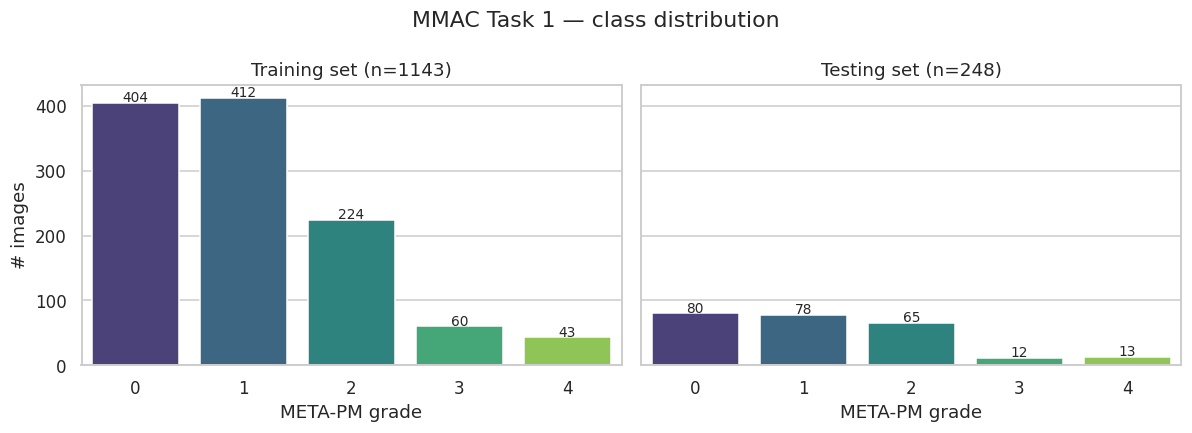

Relative frequencies (train):
  Grade 0:  35.3 %
  Grade 1:  36.0 %
  Grade 2:  19.6 %
  Grade 3:   5.2 %
  Grade 4:   3.8 %


In [10]:
# Figure 1: class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, df, name in zip(axes, [train_df, test_df], ['Training', 'Testing']):
    counts = df[LABEL_COL].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f'{name} set (n={len(df)})')
    ax.set_xlabel('META-PM grade')
    ax.set_ylabel('# images')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(int(v)), ha='center', fontsize=9)
fig.suptitle('MMAC Task 1 — class distribution')
fig.tight_layout()
plt.show()

print('Relative frequencies (train):')
rel = train_df[LABEL_COL].value_counts(normalize=True).sort_index()
for g, p in rel.items():
    print(f'  Grade {g}: {p*100:5.1f} %')


/tmp/ipykernel_3516739/2189459998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index.astype(str), y=sex_counts.values, ax=axes[1], palette='mako')
/tmp/ipykernel_3516739/2189459998.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=center_counts.index.astype(str), y=center_counts.values, ax=axes[2], palette='rocket')


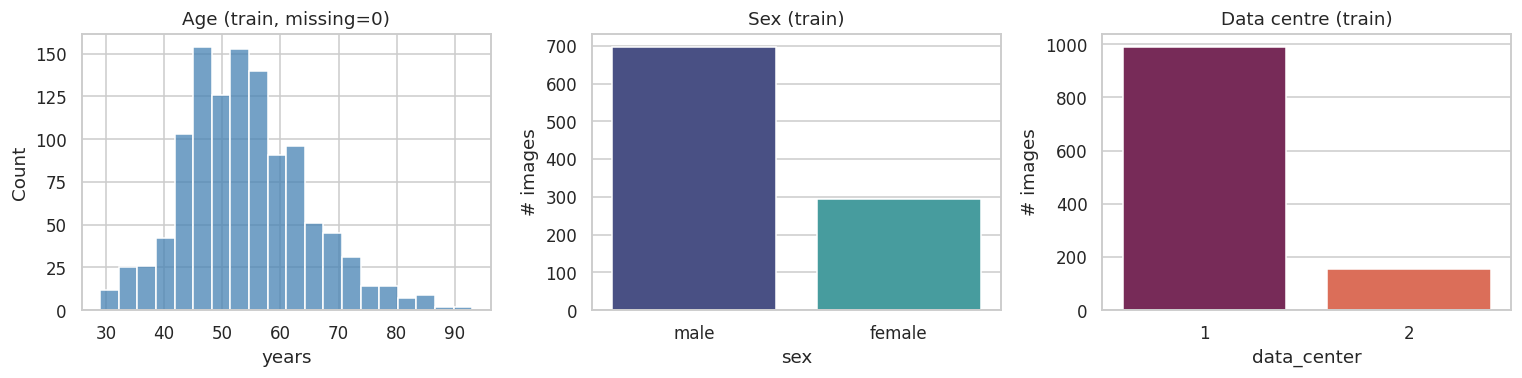


Grade x data centre (train):
data_center                 1   2
myopic_maculopathy_grade         
0                         366  38
1                         379  33
2                         187  37
3                          37  23
4                          21  22


In [11]:
# Figure 2: demographics
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

sns.histplot(train_df['age'].dropna(), bins=20, ax=axes[0], color='steelblue')
axes[0].set_title(f'Age (train, missing={train_df["age"].isna().sum()})')
axes[0].set_xlabel('years')

sex_counts = train_df['sex'].value_counts(dropna=False)
sns.barplot(x=sex_counts.index.astype(str), y=sex_counts.values, ax=axes[1], palette='mako')
axes[1].set_title('Sex (train)')
axes[1].set_ylabel('# images')

center_counts = train_df['data_center'].value_counts().sort_index()
sns.barplot(x=center_counts.index.astype(str), y=center_counts.values, ax=axes[2], palette='rocket')
axes[2].set_title('Data centre (train)')
axes[2].set_ylabel('# images')

fig.tight_layout()
plt.show()

print('\nGrade x data centre (train):')
print(pd.crosstab(train_df[LABEL_COL], train_df['data_center']))


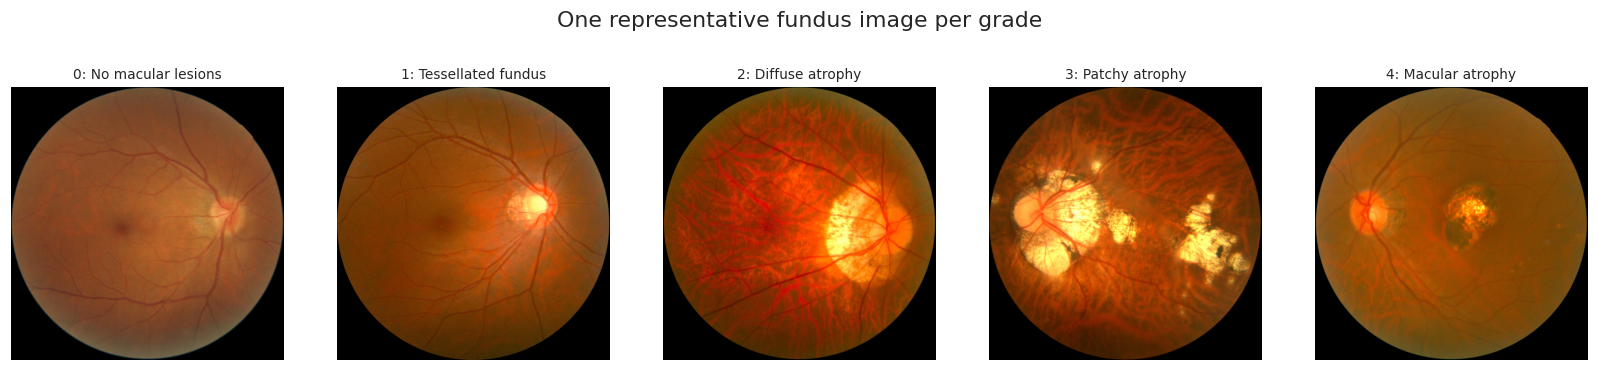

In [12]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 3.2))
for grade in range(NUM_CLASSES):
    sample = train_df[train_df[LABEL_COL] == grade].iloc[0]
    img = Image.open(TRAIN_DIR / sample[IMAGE_COL])
    axes[grade].imshow(img)
    axes[grade].axis('off')
    axes[grade].set_title(CLASS_NAMES[grade], fontsize=9)
fig.suptitle('One representative fundus image per grade', y=1.05)
fig.tight_layout()
plt.show()


## 10. Experimental setup


In [ ]:
# BASELINE_NAME = 'baseline_resnet50'
BASELINE_NAME = 'class_imbalance_resnet50'
main_config = BaselineConfig(
    seed=42,
    image_size=224,
    val_split=0.15,
    num_workers=8,
    batch_size=128,          # safe MPS default; bump to 128 on VPS
    backbone='resnet50',
    pretrained=True,
    dropout=0.3,
    epochs=30,
    head_lr=1e-3,
    backbone_lr=1e-4,
    weight_decay=1e-4,
    scheduler='cosine',
    warmup_epochs=1,
    label_smoothing=0.1,
    wegihted_ce=False,
    grad_clip=1.0,
    use_amp=True,           # auto-disabled on MPS by the engine
    early_stop_patience=7,
    primary_metric='quadratic_kappa',
    experiment_name=BASELINE_NAME,
)

EXPERIMENTS: Dict[str, Dict[str, Any]] = {
    BASELINE_NAME:         dict(),                                 # main baseline (image_size=224, aug on, 100% of train)
    f'{BASELINE_NAME}_img384':  dict(image_size=384, batch_size=8),     # higher resolution (smaller batch to fit memory)
    # f'{BASELINE_NAME}_noaug':   dict(augmentation=False),               # no random augmentation at train time
    # f'{BASELINE_NAME}_frac30':  dict(train_fraction=0.3),               # 30% of training data
    # f'{BASELINE_NAME}_frac60':  dict(train_fraction=0.6),               # 60% of training data
}


TRAIN: bool = True

device = get_device()
set_seed(main_config.seed)
enable_cuda_optimizations()
print(f'Using device: {device}')
print(f'TRAIN flag  : {TRAIN}')
print(f'Experiments : {list(EXPERIMENTS)}')


Using device: cuda
TRAIN flag  : True
Experiments : ['class_imbalance_resnet50', 'class_imbalance_resnet50_img448']


## 11. Training loop


In [ ]:
def run_experiment(exp_name: str, overrides: Dict[str, Any], device: torch.device,
                   train_if_missing: bool = True):
    """Train (or reload) one experiment and save every artefact the
    downstream analysis cells expect.

    Returns a dict with the TrainResult (or None if skipped) and the full
    per-sample predictions on the test set.
    """
    cfg = replace(main_config, experiment_name=exp_name, **overrides)
    best_ckpt = cfg.checkpoint_dir / f"{exp_name}_best.pt"
    history_path = cfg.output_dir / f"{exp_name}_history.json"

    already_trained = best_ckpt.exists() and history_path.exists()
    if not already_trained and not train_if_missing:
        print(f'[{exp_name}] no checkpoint and TRAIN=False — skipping')
        return None

    if not already_trained:
        print(f'\n=== [{exp_name}] training from scratch ===')
        set_seed(cfg.seed)
        loaders = build_dataloaders(cfg)
        print(f'  train={len(loaders["train_ds"])}  val={len(loaders["val_ds"])}  '
              f'test={len(loaders["test_ds"])}')
        best_model = build_model(cfg)
        result = train(best_model, loaders, cfg, device)
    else:
        print(f'[{exp_name}] checkpoint found — reloading artefacts')
        result = load_trained_result(cfg)
        loaders = build_dataloaders(cfg)  # needed for a clean evaluation pass

        best_model = build_model(cfg).to(device)
    load_checkpoint(best_ckpt, model=best_model, map_location=device)
    best_model.eval()
    # CHANGED
    # class_weights = torch.tensor([0.05025997, 0.05025997, 0.09185442, 0.33968804, 0.46793761], dtype=torch.float)

    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    if cfg.class_weights:
        class_weights = inverse_frequency_weights(loaders["train_ds"])
        print("Loss class weights: ", class_weights)
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing, weight=class_weights)
        

    val_loss, val_bundle, val_y, val_yp, val_prob = evaluate(
        best_model, loaders['val'], criterion, device, desc=f'{exp_name} val')
    test_loss, test_bundle, test_y, test_yp, test_prob = evaluate(
        best_model, loaders['test'], criterion, device, desc=f'{exp_name} test')

    print(f'[{exp_name}] VAL  loss={val_loss:.4f}  {val_bundle.pretty()}')
    print(f'[{exp_name}] TEST loss={test_loss:.4f}  {test_bundle.pretty()}')

    summary = {
        'experiment': exp_name,
        'device': str(device),
        'best_epoch': result.best_epoch + 1,
        'best_val_metric': result.best_metric,
        'primary_metric': result.primary_metric,
        'val': val_bundle.to_dict(),
        'test': test_bundle.to_dict(),
        'config': {k: (str(v) if isinstance(v, Path) else v)
                   for k, v in cfg.__dict__.items()},
    }
    (cfg.output_dir / f"{exp_name}_summary.json").write_text(
        json.dumps(summary, indent=2, default=str)
    )
    np.savez_compressed(
        cfg.output_dir / f"{exp_name}_test_predictions.npz",
        y_true=test_y.astype(np.int64),
        y_pred=test_yp.astype(np.int64),
        y_prob=test_prob.astype(np.float32),
    )
    np.savez_compressed(
        cfg.output_dir / f"{exp_name}_val_predictions.npz",
        y_true=val_y.astype(np.int64),
        y_pred=val_yp.astype(np.int64),
        y_prob=val_prob.astype(np.float32),
    )
    return {'result': result, 'config': cfg, 'val_bundle': val_bundle,
            'test_bundle': test_bundle}

experiment_outputs: Dict[str, Any] = {}
for exp_name, overrides in EXPERIMENTS.items():
    out = run_experiment(exp_name, overrides, device, train_if_missing=TRAIN)
    if out is not None:
        experiment_outputs[exp_name] = out

print(f'\nCompleted {len(experiment_outputs)} / {len(EXPERIMENTS)} experiments')



=== [class_imbalance_resnet50] training from scratch ===
Class weights:  tensor([0.0029, 0.0029, 0.0053, 0.0196, 0.0270])
  train=971  val=172  test=248
[train] device=cuda  epochs=30  batch_size=128  primary_metric=quadratic_kappa


train 1/30:   0%|          | 0/7 [00:00<?, ?it/s]

val   1/30:   0%|          | 0/2 [00:00<?, ?it/s]

[epoch 01/30] * train loss=2.0118 acc=0.4096  bal_acc=0.3636  macroF1=0.3257  kappa=0.3274  AUROC=  n/a | val loss=2.1711 acc=0.5523  bal_acc=0.3705  macroF1=0.3603  kappa=0.5716  AUROC=0.8449 | lr=[1.00e-04, 1.00e-03] | 6.3s


train 2/30:   0%|          | 0/7 [00:00<?, ?it/s]

...

val   26/30:   0%|          | 0/22 [00:00<?, ?it/s]

[epoch 26/30]   train loss=0.8582 acc=0.9773  bal_acc=0.9868  macroF1=0.9786  kappa=0.9772  AUROC=  n/a | val loss=1.2296 acc=0.8663  bal_acc=0.7976  macroF1=0.7996  kappa=0.9272  AUROC=0.9160 | lr=[4.62e-06, 4.62e-05] | 4.9s
[train] Early stopping at epoch 26: no improvement on quadratic_kappa for 7 epochs.


class_imbalance_resnet50_img448 val:   0%|          | 0/22 [00:00<?, ?it/s]

class_imbalance_resnet50_img448 test:   0%|          | 0/31 [00:00<?, ?it/s]

[class_imbalance_resnet50_img448] VAL  loss=1.2561  acc=0.8837  bal_acc=0.8127  macroF1=0.8124  kappa=0.9365  AUROC=0.9214
[class_imbalance_resnet50_img448] TEST loss=1.4522  acc=0.7702  bal_acc=0.6888  macroF1=0.6926  kappa=0.7980  AUROC=0.8939

Completed 2 / 2 experiments


## 12. Main baseline evaluation with bootstrap CIs


In [79]:
RESULTS_AVAILABLE = BASELINE_NAME in experiment_outputs

if RESULTS_AVAILABLE:
    base = experiment_outputs[f'{BASELINE_NAME}']
    base_cfg = base['config']
    base_result = base['result']
    val_bundle  = base['val_bundle']
    test_bundle = base['test_bundle']

    print(f'Main baseline: {BASELINE_NAME}')
    print(f'  best epoch    : {base_result.best_epoch + 1}')
    print(f'  best val {base_result.primary_metric}: {base_result.best_metric:.4f}')
    print()
    print(f'VAL  : {val_bundle.pretty()}')
    print(f'TEST : {test_bundle.pretty()}')


    val_preds = np.load(base_cfg.output_dir / f'{BASELINE_NAME}_val_predictions.npz')
    val_y_main  = val_preds['y_true']
    val_yp_main = val_preds['y_pred']
    val_prob_main = val_preds['y_prob']

    test_preds = np.load(base_cfg.output_dir / f'{BASELINE_NAME}_test_predictions.npz')
    test_y_main  = test_preds['y_true']
    test_yp_main = test_preds['y_pred']
    test_prob_main = test_preds['y_prob']
else:
    print('Main baseline not yet trained.')
    print('Set TRAIN = True above and re-run, or copy the VPS artefacts into outputs/baseline/.')


Main baseline: class_imbalance_resnet50
  best epoch    : 15
  best val quadratic_kappa: 0.8953

VAL  : acc=0.8256  bal_acc=0.8000  macroF1=0.7770  kappa=0.8953  AUROC=0.9302
TEST : acc=0.7137  bal_acc=0.6094  macroF1=0.6237  kappa=0.7920  AUROC=0.8760


In [80]:
if RESULTS_AVAILABLE:
    ci = bootstrap_metrics(
        test_y_main, test_yp_main, test_prob_main,
        n_resamples=1000, ci_level=0.95, seed=main_config.seed,
    )
    print(f'Main baseline test-set bootstrap CIs ({BASELINE_NAME}):')
    for name, entry in ci.items():
        print(f'  {name:20s} {format_ci(entry)}')

    ci_df = pd.DataFrame([
        {'metric': m, 'point': round(e['point'], 4),
         'ci_low': round(e['ci_low'], 4), 'ci_high': round(e['ci_high'], 4),
         'std': round(e['std'], 4)}
        for m, e in ci.items()
    ])
    ci_df.to_csv(base_cfg.output_dir / f'{BASELINE_NAME}_test_bootstrap_ci.csv', index=False)
    display(ci_df)
else:
    print('Skipped: no baseline results available.')


Main baseline test-set bootstrap CIs (class_imbalance_resnet50):
  accuracy             0.7137  [0.6573, 0.7702]
  balanced_accuracy    0.6094  [0.5148, 0.6950]
  macro_f1             0.6237  [0.5250, 0.7093]
  weighted_f1          0.7113  [0.6539, 0.7662]
  quadratic_kappa      0.7920  [0.7105, 0.8592]
  macro_auroc          0.8760  [0.8255, 0.9169]


,metric,point,ci_low,ci_high,std
0,accuracy,0.7137,0.6573,0.7702,0.0289
1,balanced_accuracy,0.6094,0.5148,0.6950,0.0442
2,macro_f1,0.6237,0.5250,0.7093,0.0457
3,weighted_f1,0.7113,0.6539,0.7662,0.0293
4,quadratic_kappa,0.7920,0.7105,0.8592,0.0387
5,macro_auroc,0.8760,0.8255,0.9169,0.0232


In [81]:
per_class = pd.DataFrame({
    'class'    : list(CLASS_NAMES),
    'support'  : test_bundle.per_class_support,
    'precision': test_bundle.per_class_precision,
    'recall'   : test_bundle.per_class_recall,
    'f1'       : test_bundle.per_class_f1,
}).round(4)
per_class.to_csv(base_cfg.output_dir / f'{BASELINE_NAME}_test_per_class.csv', index=False)
per_class


,class,support,precision,recall,f1
0,0: No macular lesions,80,0.7674,0.8250,0.7952
1,1: Tessellated fundus,78,0.6341,0.6667,0.6500
2,2: Diffuse atrophy,65,0.8167,0.7538,0.7840
3,3: Patchy atrophy,12,0.4545,0.4167,0.4348
4,4: Macular atrophy,13,0.5556,0.3846,0.4545


## 13. Visualisation


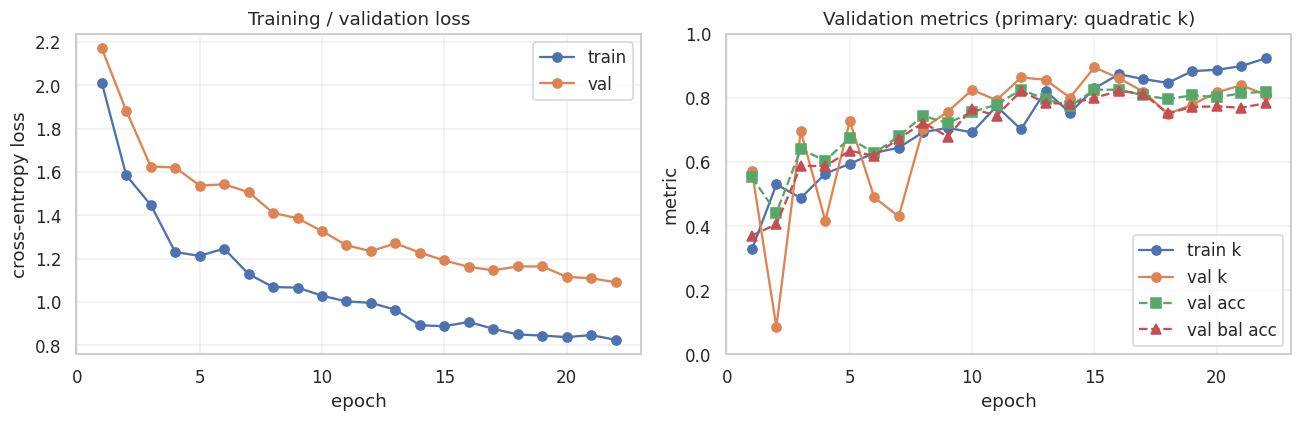

In [82]:
# Training / validation curves
fig = plot_training_curves(
    base_result.history,
    save_path=base_cfg.output_dir / f'{BASELINE_NAME}_training_curves.png',
)
plt.show()


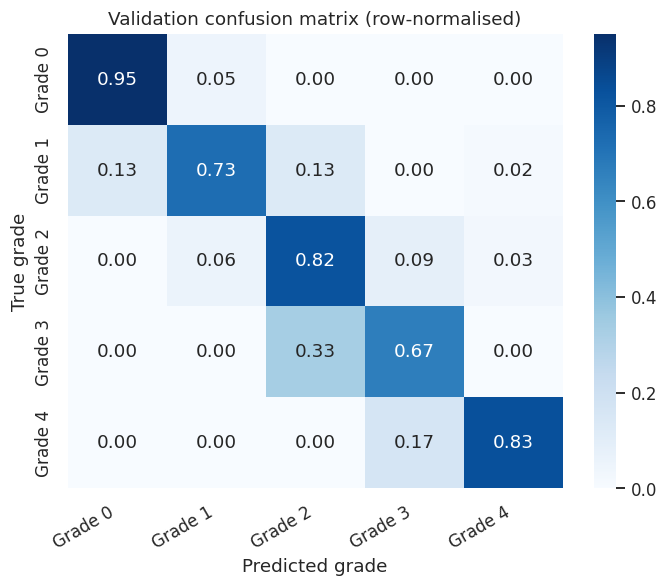

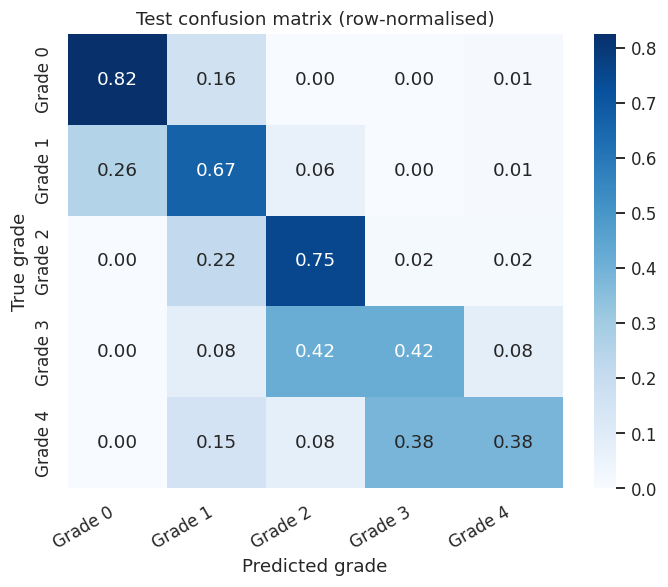

In [83]:
if RESULTS_AVAILABLE:
    short_names = [f'Grade {i}' for i in range(NUM_CLASSES)]

    fig_val = plot_confusion_matrix(
        np.array(val_bundle.confusion_matrix), short_names,
        title='Validation confusion matrix',
        save_path=base_cfg.output_dir / f'{BASELINE_NAME}_cm_val.png',
    )
    plt.show()
    fig_test = plot_confusion_matrix(
        np.array(test_bundle.confusion_matrix), short_names,
        title='Test confusion matrix',
        save_path=base_cfg.output_dir / f'{BASELINE_NAME}_cm_test.png',
    )
    plt.show()
else:
    print('Skipped: no evaluation results available.')


## 14. Ablation analysis


In [84]:
def load_experiment_artefacts(exp_name: str) -> Optional[Dict[str, Any]]:
    """Load summary + history + test/val predictions for one experiment.

    Returns None if the artefacts are missing (e.g. the user ran with
    TRAIN=False and that experiment wasn't previously trained).
    """
    out_dir = OUTPUT_DIR / 'baseline'
    paths = {
        'summary'   : out_dir / f'{exp_name}_summary.json',
        'history'   : out_dir / f'{exp_name}_history.json',
        'test_preds': out_dir / f'{exp_name}_test_predictions.npz',
        'val_preds' : out_dir / f'{exp_name}_val_predictions.npz',
    }
    if not all(p.is_file() for p in paths.values()):
        return None
    summary = json.loads(paths['summary'].read_text())
    history = json.loads(paths['history'].read_text())
    test    = np.load(paths['test_preds'])
    val     = np.load(paths['val_preds'])
    return {
        'name'     : exp_name,
        'summary'  : summary,
        'history'  : history,
        'test_y'   : test['y_true'], 'test_yp'  : test['y_pred'], 'test_prob': test['y_prob'],
        'val_y'    : val['y_true'],  'val_yp'   : val['y_pred'],  'val_prob' : val['y_prob'],
    }

PRETTY = {
    BASELINE_NAME        : 'Baseline (224, aug on, 100 %)',
    f'{BASELINE_NAME}_img384' : 'Image size 384',
    f'{BASELINE_NAME}_noaug'  : 'No augmentation',
    f'{BASELINE_NAME}_frac30' : 'Train 30 %',
    f'{BASELINE_NAME}_frac60' : 'Train 60 %',
}
runs = {name: art for name in EXPERIMENTS if (art := load_experiment_artefacts(name)) is not None}
print(f'Loaded {len(runs)} / {len(EXPERIMENTS)} experiments for ablation analysis:')
for name in runs:
    print(f'  {name}')
missing = [n for n in EXPERIMENTS if n not in runs]
if missing:
    print(f'Missing (skipped gracefully): {missing}')


Loaded 2 / 2 experiments for ablation analysis:
  class_imbalance_resnet50
  class_imbalance_resnet50_img448


In [87]:
def compare_to_baseline(target_name: str, metric: str = 'quadratic_kappa'):
    if target_name not in runs or BASELINE_NAME not in runs:
        return None
    a = runs[target_name]
    b = runs[BASELINE_NAME]
    return paired_bootstrap_compare(
        a['test_y'], a['test_yp'], b['test_yp'],
        a['test_prob'], b['test_prob'],
        metric=metric, n_resamples=2000, seed=main_config.seed,
    )

def summarise_comparison(name: str, cmp: Optional[Dict[str, float]]):
    if cmp is None:
        return None
    return {
        'experiment'         : PRETTY[name] if name in PRETTY else name,
        'kappa'              : round(cmp['metric_a'], 4),
        'kappa_baseline'     : round(cmp['metric_b'], 4),
        'delta'              : round(cmp['delta'], 4),
        'ci_low'             : round(cmp['ci_low'], 4),
        'ci_high'            : round(cmp['ci_high'], 4),
        'p_value'            : round(cmp['p_value'], 4),
        'significant_at_5pct': cmp['p_value'] < 0.05,
    }


### Ablation 1 - image size (224 vs 384)


In [36]:
img_cmp = compare_to_baseline(f'{BASELINE_NAME}_img384')
row = summarise_comparison(f'{BASELINE_NAME}_img384', img_cmp)
pd.DataFrame([row]) if row is not None else 'Image-size ablation not yet available.'


,experiment,kappa,kappa_baseline,delta,ci_low,ci_high,p_value,significant_at_5pct
0,Image size 384,0.8237,0.7407,0.0831,0.0208,0.1618,0.003,True


### Ablation 2 - augmentation on vs off


In [37]:
aug_cmp = compare_to_baseline(f'{BASELINE_NAME}_noaug')
row = summarise_comparison(f'{BASELINE_NAME}_noaug', aug_cmp)
pd.DataFrame([row]) if row is not None else 'Augmentation ablation not yet available.'


,experiment,kappa,kappa_baseline,delta,ci_low,ci_high,p_value,significant_at_5pct
0,No augmentation,0.8671,0.7407,0.1264,0.049,0.2157,0.001,True


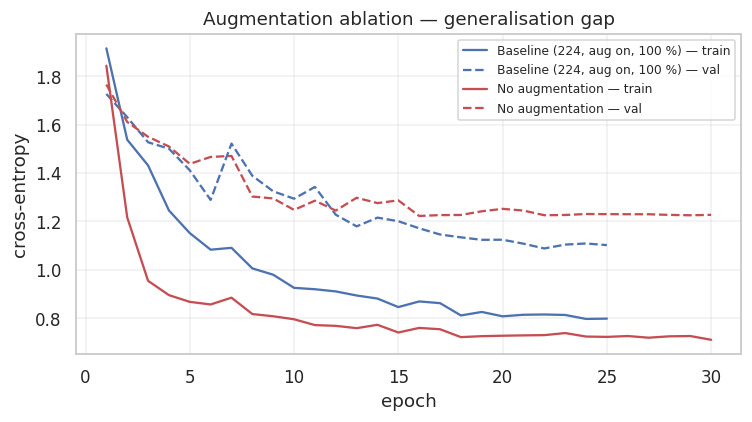

In [38]:
if f'{BASELINE_NAME}_noaug'in runs:
    fig, ax = plt.subplots(figsize=(7, 4))
    for run_name, colour in zip([BASELINE_NAME, f'{BASELINE_NAME}_noaug'], ['C0', 'C3']):
        h = runs[run_name]['history']
        ep = np.arange(1, len(h['train_loss']) + 1)
        ax.plot(ep, h['train_loss'], color=colour,
                label=f'{PRETTY[run_name]} — train', linestyle='-')
        ax.plot(ep, h['val_loss'], color=colour,
                label=f'{PRETTY[run_name]} — val', linestyle='--')
    ax.set_xlabel('epoch')
    ax.set_ylabel('cross-entropy')
    ax.set_title('Augmentation ablation — generalisation gap')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'baseline' / 'ablation_augmentation_gap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Augmentation ablation not yet available.')


### Combined ablation table


In [88]:
rows = []
# for name in ['baseline_resnet50_img384', 'baseline_resnet50_noaug',
#              'baseline_resnet50_frac30', 'baseline_resnet50_frac60']:
for name in EXPERIMENTS:
    if name not in runs:
        continue
    r = summarise_comparison(name, compare_to_baseline(name))
    if r is not None:
        rows.append(r)

if BASELINE_NAME in runs:
    base_ci = bootstrap_metrics(
        runs[BASELINE_NAME]['test_y'],
        runs[BASELINE_NAME]['test_yp'],
        runs[BASELINE_NAME]['test_prob'],
        n_resamples=1000, seed=main_config.seed,
    )
    rows.insert(0, {
        'experiment'         : PRETTY[BASELINE_NAME],
        'kappa'              : round(base_ci['quadratic_kappa']['point'], 4),
        'kappa_baseline'     : round(base_ci['quadratic_kappa']['point'], 4),
        'delta'              : 0.0,
        'ci_low'             : None,
        'ci_high'            : None,
        'p_value'            : None,
        'significant_at_5pct': None,
    })

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(OUTPUT_DIR / 'baseline' / 'ablation_summary_table.csv', index=False)
ablation_df


,experiment,kappa,kappa_baseline,delta,ci_low,ci_high,p_value,significant_at_5pct
0,"Baseline (224, aug on, 100 %)",0.792,0.792,0.000,NaN,NaN,NaN,None
1,"Baseline (224, aug on, 100 %)",0.792,0.792,0.000,0.000,0.0000,1.000,False
2,class_imbalance_resnet50_img448,0.798,0.792,0.006,-0.072,0.0877,0.922,False


### Ablation 4 - training-set learning curve


In [40]:
curve_points = [
    (0.3, f'{BASELINE_NAME}_frac30'),
    (0.6, f'{BASELINE_NAME}_frac60'),
    (1.0, BASELINE_NAME),
]

curve_rows = []
for frac, name in curve_points:
    if name not in runs:
        continue
    r = runs[name]
    ci_r = bootstrap_metrics(
        r['test_y'], r['test_yp'], r['test_prob'],
        n_resamples=1000, seed=main_config.seed,
    )['quadratic_kappa']
    curve_rows.append({
        'fraction': frac,
        'n_train' : int(round(frac * 971)),  # 971 = size of the stratified train split
        'kappa'   : round(ci_r['point'], 4),
        'ci_low'  : round(ci_r['ci_low'], 4),
        'ci_high' : round(ci_r['ci_high'], 4),
    })

curve_df = pd.DataFrame(curve_rows).sort_values('fraction').reset_index(drop=True)
curve_df.to_csv(OUTPUT_DIR / 'baseline' / 'ablation_learning_curve.csv', index=False)
curve_df


,fraction,n_train,kappa,ci_low,ci_high
0,0.3,291,0.6356,0.5430,0.7121
1,0.6,583,0.6155,0.5304,0.6896
2,1.0,971,0.7407,0.6499,0.8225


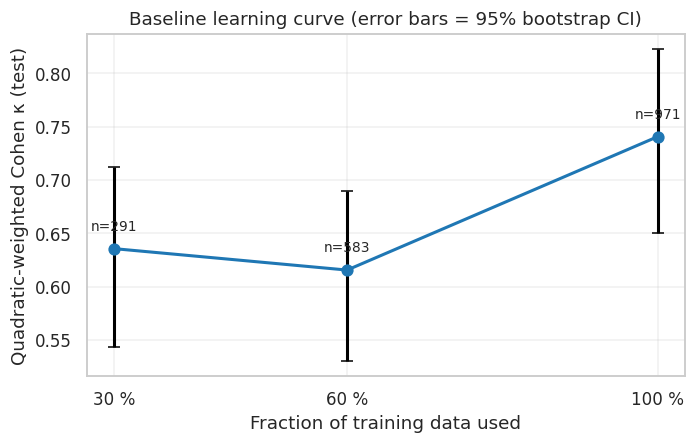

In [41]:
if not curve_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    fractions = curve_df['fraction'].values
    kappas    = curve_df['kappa'].values
    lo_err = kappas - curve_df['ci_low'].values
    hi_err = curve_df['ci_high'].values - kappas

    ax.errorbar(fractions, kappas, yerr=[lo_err, hi_err],
                marker='o', capsize=4, linewidth=2, markersize=7,
                color='#1f77b4', ecolor='black')
    ax.set_xlabel('Fraction of training data used')
    ax.set_ylabel('Quadratic-weighted Cohen κ (test)')
    ax.set_title('Baseline learning curve (error bars = 95% bootstrap CI)')
    ax.set_xticks(fractions)
    ax.set_xticklabels([f'{int(f*100)} %' for f in fractions])
    ax.grid(True, alpha=0.3)
    for x, y, n in zip(fractions, kappas, curve_df['n_train']):
        ax.annotate(f'n={n}', xy=(x, y), xytext=(0, 12),
                    textcoords='offset points', ha='center', fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'baseline' / 'ablation_learning_curve.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Learning-curve runs not yet available.')
